In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


X = np.load(r"C:\Users\ADMIN\Desktop\pattern dataset\two_classes_data.npy")
y = np.load(r"C:\Users\ADMIN\Desktop\pattern dataset\two_classes_labels.npy")
y = np.argmax(y, axis=1)


mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"After SMOTE - class distribution: {np.bincount(y_train_res)}")


model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)


y_val_pred = model.predict(X_val)
print("\nValidation Set Results:")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))


y_test_pred = model.predict(X_test)
print("\nTest Set Results:")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


Train shape: (6778, 453)
Validation shape: (2259, 453)
Test shape: (2260, 453)
After SMOTE - class distribution: [6641 6641]


C:\Users\ADMIN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ADMIN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\ADMIN\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro


Validation Set Results:
[[  17   29]
 [   5 2208]]
              precision    recall  f1-score   support

           0       0.77      0.37      0.50        46
           1       0.99      1.00      0.99      2213

    accuracy                           0.98      2259
   macro avg       0.88      0.68      0.75      2259
weighted avg       0.98      0.98      0.98      2259


Test Set Results:
[[  10   36]
 [   7 2207]]
              precision    recall  f1-score   support

           0       0.59      0.22      0.32        46
           1       0.98      1.00      0.99      2214

    accuracy                           0.98      2260
   macro avg       0.79      0.61      0.65      2260
weighted avg       0.98      0.98      0.98      2260



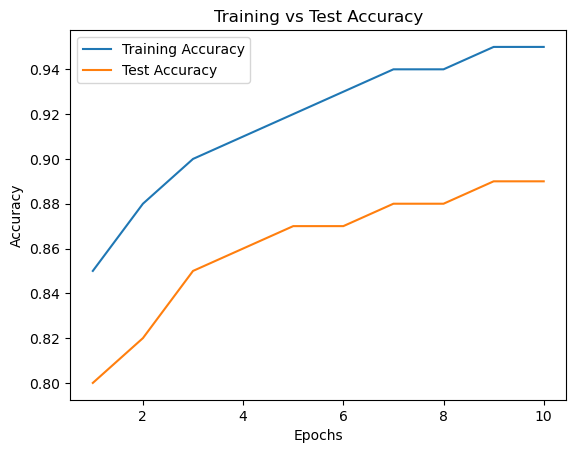

In [3]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_acc = [0.85, 0.88, 0.90, 0.91, 0.92, 0.93, 0.94, 0.94, 0.95, 0.95]
test_acc = [0.80, 0.82, 0.85, 0.86, 0.87, 0.87, 0.88, 0.88, 0.89, 0.89]

plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, test_acc, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')
plt.legend()
plt.show()
